In [1]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import cmasher as cmr
import pandas as pd
from astropy.table import Table, vstack
import scipy

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
import importlib
sys.path.append('../code/')
import helper

In [5]:
tbl = Table.read('../data/kiyan-mssa_prep_table_with_time.fits')
tbl.sort(["timestep", "jphi_cen", "tphi_cen"])

In [6]:
jphi_c = np.arange(1000, 3000+1, 100)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
centers = np.array(np.meshgrid(jphi_c, tphi_c)).T.reshape(-1,2)

cfs_m0_amp    = ['m0_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_amp    = ['m1_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_amp    = ['m2_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_pitch  = ['m1_pitch_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_pitch  = ['m2_pitch_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_phase  = ['m1_phase_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_phase  = ['m2_phase_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m1_int_time = ['m1_int_time_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2_int_time = ['m2_int_time_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]

colnames = ['timestep']+cfs_m0_amp+cfs_m1_amp+cfs_m2_amp+cfs_m1_pitch+cfs_m2_pitch+cfs_m1_phase+cfs_m2_phase+cfs_m1_int_time+cfs_m2_int_time

t = Table(names=colnames)

for time in np.unique(tbl['timestep']):
    subset = tbl[tbl['timestep'] == time]
    channels = np.concatenate([np.array(subset['m0_amp']), np.array(subset['m1_amp']), np.array(subset['m2_amp']),
                               np.array(subset['pitch_ang_m1']), np.array(subset['pitch_ang_m2']), 
                               np.array(subset['phase_ang_m1']), np.array(subset['phase_ang_m2']),
                               np.array(time*0.01 - subset['time_since_int_m1']),
                               np.array(time*0.01 - subset['time_since_int_m2'])])
    #amps = np.concatenate((subset['m1_amp'], subset['m2_amp']))
    t.add_row(np.append([time], channels))

In [7]:
t

<Table length=300>
timestep m0_amp_1000_1pi16  ... m2_int_time_3000_29pi16 m2_int_time_3000_31pi16
float64       float64       ...         float64                 float64        
-------- ------------------ ... ----------------------- -----------------------
     0.0   214741.595715466 ...     -0.3873392077182662    -0.03562990455429609
     1.0 214725.80814926932 ...    -0.40182608655648033     -0.7384883645560134
     2.0 214738.89291186637 ...     -0.6126618130179382     -0.5037178112935379
     3.0 214649.68348473264 ...     0.02999999999390111    0.029999999999992595
     4.0  214262.2734149934 ...     -2.9115181923114895      0.0399999999999998
     5.0 214324.76384544943 ...     -0.2005844928165053     0.04999999999998643
     6.0 214438.15434792146 ...    -0.20053843084281986    0.059999995957627096
     7.0 214834.70102171754 ...   -0.050164969150132674     -0.2678618788328878
     8.0 214658.09330863712 ...     -0.9227366452443521    -0.20116444348145834
     ...                ... ...                     ...                     ...
   290.0  215374.7801839383 ...      2.1178280770839493       2.034044298904567
   291.0 214439.61612404077 ...      2.8661265249337897      1.8618104586296709
   292.0 214694.61533840446 ...       2.697093412301784       2.820200051274331
   293.0  214283.0610124674 ...       2.861142434805359                    2.93
   294.0  214775.5086960611 ...      2.9208960145416394      2.9399999999999977
   295.0 214583.96984260794 ...                    2.95      2.5822671357530487
   296.0 214316.93602058684 ...      2.5228745353648607       1.673100131458976
   297.0  215159.4136452178 ...        2.81807378204866                    2.97
   298.0 214828.81627308027 ...      2.6929743011324856      2.2800258568460046
   299.0  214754.4118411035 ...       2.644865462538712       2.989999999999833

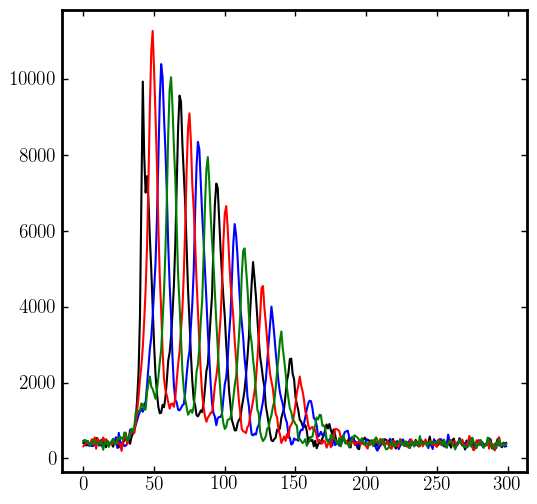

In [20]:
%matplotlib inline
fig, ax = plt.subplots(1,1,figsize=(6,6))

ax.plot(t['timestep'], t['m1_amp_2000_1pi16'])
ax.plot(t['timestep'], t['m1_amp_2000_17pi16'])
ax.plot(t['timestep'], t['m1_amp_2000_9pi16'])
ax.plot(t['timestep'], t['m1_amp_2000_25pi16'])
plt.show()

## Coefficient Errors

From the Laguerre basis contruction, we can calculate the errors on coefficients as well as the coefficients themselves

I have this from the initial calculation but I did not save them :(